# Viettel AI 2026 — 3DGS pipeline test (Kaggle T4)

Notebook **tự chứa toàn bộ code**: chạy tuần tự từ trên xuống là xong 1 scene
(prepare → train 7000 iter → render test poses → PSNR → xem ảnh).

**Trước khi chạy:**
1. Settings → Accelerator = **GPU T4 x2** (hoặc T4), **Internet = On**.
2. **Add Input** → dataset chứa `public_set` / `private_set1`.
3. Sửa `DATA_ROOT` ở cell config cho khớp đường dẫn dataset.

Data gốc có 2 bẫy (đã xử lý trong `prepare_scene.py`, bắt buộc chạy trước train):
- `cameras.bin` là **SIMPLE_RADIAL** → 3DGS gốc assert lỗi.
- `images.bin` chứa nhiều entry hơn số ảnh phát hành (gồm cả pose test).

In [16]:
import os
print("Datasets đã attach:", os.listdir("/kaggle/input"))

DATA_ROOT  = "/kaggle/input/datasets/huphcphmquang/viettel-ai-2026/phase1/private_set1"   # <-- khớp theo listdir in ra ở trên
SCENE_NAME = "HCM0249"                            # <-- scene muốn chạy thử
ITERS      = 7000

SCENE = f"{DATA_ROOT}/{SCENE_NAME}"
PREP  = f"/kaggle/working/scenes/{SCENE_NAME}"
MODEL = f"/kaggle/working/output/{SCENE_NAME}"
PIPE  = "/kaggle/working/pipeline"
os.makedirs(PIPE, exist_ok=True)
assert os.path.isdir(SCENE), f"Không thấy scene: {SCENE} — sửa DATA_ROOT/SCENE_NAME"
print("Scene:", SCENE)

In [ ]:
# (Resume) Khôi phục output từ version trước — bỏ qua nếu chạy lần đầu
import shutil, os, glob
cands = (glob.glob("/kaggle/input/*/output/status.json") +
         glob.glob("/kaggle/input/*/*/output/status.json") +
         glob.glob("/kaggle/input/datasets/*/*/output/status.json"))
if cands:
    prev = os.path.dirname(cands[0])
    shutil.copytree(prev, "/kaggle/working/output", dirs_exist_ok=True)
    print("Đã khôi phục output từ:", prev)
    print(open("/kaggle/working/output/status.json").read())
else:
    print("Không thấy output version trước — chạy mới từ đầu")

## 1. Ghi các script pipeline ra /kaggle/working/pipeline

In [17]:
%%writefile /kaggle/working/pipeline/prepare_scene.py
"""
Chuẩn hoá 1 scene về dạng 3DGS train được, xuất ra thư mục ghi được.

Vấn đề của data gốc (đã xác minh trên mọi scene):
  1. cameras.bin dùng model SIMPLE_RADIAL (f, cx, cy, k) -> train.py của 3DGS
     assert vì chỉ nhận PINHOLE/SIMPLE_PINHOLE.
  2. images.bin chứa NHIỀU entry hơn số ảnh phát hành (gồm cả ảnh test và ảnh
     không có file) -> crash thiếu file + leak pose test vào train.
  3. Hệ số méo k đa số nhỏ (~0.008) nhưng HNI0131 k=-0.115 (méo mạnh).

Script này:
  - Undistort ảnh train bằng cv2 (k1, đúng convention COLMAP SIMPLE_RADIAL)
    nếu |k| > --k-thresh, ngược lại copy/symlink ảnh gốc.
  - Ghi cameras.bin mới: PINHOLE (fx=fy=f, cx, cy).
  - Lọc images.bin: chỉ giữ entry có file trong train/images (copy raw bytes
    từng entry nên nhanh, không cần decode points2D).
  - Copy points3D.bin / points3D.ply. Bỏ frames.bin/rigs.bin (3DGS không đọc).

Dùng:
    python prepare_scene.py --scene /kaggle/input/vt2026/public_set/hcm0031 \
                            --out   /kaggle/working/scenes/hcm0031
Sau đó train với:  -s /kaggle/working/scenes/hcm0031/train
"""
import os
import shutil
import struct
import argparse

CAMERA_MODELS = {0: "SIMPLE_PINHOLE", 1: "PINHOLE", 2: "SIMPLE_RADIAL",
                 3: "RADIAL", 4: "OPENCV", 5: "OPENCV_FISHEYE"}
MODEL_NUM_PARAMS = {0: 3, 1: 4, 2: 4, 3: 5, 4: 8, 5: 8}


def read_cameras_bin(path):
    with open(path, "rb") as f:
        num = struct.unpack("<Q", f.read(8))[0]
        cams = []
        for _ in range(num):
            cam_id, model_id = struct.unpack("<ii", f.read(8))
            w, h = struct.unpack("<QQ", f.read(16))
            n = MODEL_NUM_PARAMS[model_id]
            params = struct.unpack("<" + "d" * n, f.read(8 * n))
            cams.append(dict(id=cam_id, model=model_id, w=w, h=h, params=params))
    return cams


def write_pinhole_cameras_bin(path, cams):
    """Ghi cameras.bin với mọi camera đã quy về PINHOLE (fx, fy, cx, cy)."""
    with open(path, "wb") as f:
        f.write(struct.pack("<Q", len(cams)))
        for c in cams:
            fx, fy, cx, cy = c["pinhole"]
            f.write(struct.pack("<ii", c["id"], 1))          # model 1 = PINHOLE
            f.write(struct.pack("<QQ", c["w"], c["h"]))
            f.write(struct.pack("<dddd", fx, fy, cx, cy))


def filter_images_bin(src, dst, keep_names):
    """Giữ lại các entry có tên trong keep_names. Copy raw bytes từng entry."""
    data = open(src, "rb").read()
    num = struct.unpack("<Q", data[:8])[0]
    off = 8
    kept = []
    for _ in range(num):
        start = off
        off += 4 + 32 + 24 + 4                    # id + qvec + tvec + cam_id
        name_start = off
        while data[off] != 0:
            off += 1
        name = data[name_start:off].decode("utf-8")
        off += 1                                   # null
        n2d = struct.unpack("<Q", data[off:off + 8])[0]
        off += 8 + n2d * 24                        # x,y (2d) + point3D_id (q)
        if name in keep_names:
            kept.append(data[start:off])
    with open(dst, "wb") as f:
        f.write(struct.pack("<Q", len(kept)))
        for chunk in kept:
            f.write(chunk)
    return num, len(kept)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--scene", required=True, help="thư mục scene gốc (read-only OK)")
    ap.add_argument("--out", required=True, help="thư mục xuất (ghi được)")
    ap.add_argument("--k-thresh", type=float, default=1e-3,
                    help="|k| lớn hơn ngưỡng này thì undistort ảnh")
    ap.add_argument("--copy-images", action="store_true",
                    help="copy ảnh thay vì symlink (khi symlink không dùng được)")
    args = ap.parse_args()

    src_sparse = os.path.join(args.scene, "train", "sparse", "0")
    src_images = os.path.join(args.scene, "train", "images")
    dst_train = os.path.join(args.out, "train")
    dst_sparse = os.path.join(dst_train, "sparse", "0")
    dst_images = os.path.join(dst_train, "images")
    os.makedirs(dst_sparse, exist_ok=True)

    # ---- 1. Camera: SIMPLE_RADIAL -> PINHOLE ----
    cams = read_cameras_bin(os.path.join(src_sparse, "cameras.bin"))
    need_undistort = False
    for c in cams:
        m = c["model"]
        if m == 1:                                  # PINHOLE sẵn
            c["pinhole"] = c["params"]
            c["k"] = 0.0
        elif m == 0:                                # SIMPLE_PINHOLE: f,cx,cy
            f_, cx, cy = c["params"]
            c["pinhole"] = (f_, f_, cx, cy)
            c["k"] = 0.0
        elif m in (2, 3):                           # SIMPLE_RADIAL / RADIAL
            f_, cx, cy, k = c["params"][:4]
            c["pinhole"] = (f_, f_, cx, cy)
            c["k"] = k
            if abs(k) > args.k_thresh:
                need_undistort = True
        else:
            raise SystemExit(f"Camera model {CAMERA_MODELS.get(m, m)} chưa hỗ trợ")
        print(f"[camera] id={c['id']} {CAMERA_MODELS[m]} k={c['k']:.5f} "
              f"-> PINHOLE {tuple(round(p, 2) for p in c['pinhole'])}"
              f"{'  (sẽ undistort ảnh)' if abs(c['k']) > args.k_thresh else ''}")
    write_pinhole_cameras_bin(os.path.join(dst_sparse, "cameras.bin"), cams)

    # ---- 2. images.bin: lọc theo file thực có ----
    train_files = set(os.listdir(src_images))
    total, kept = filter_images_bin(os.path.join(src_sparse, "images.bin"),
                                    os.path.join(dst_sparse, "images.bin"),
                                    train_files)
    print(f"[images.bin] {total} entry -> giữ {kept} (khớp {len(train_files)} file train)")

    # ---- 3. points3D ----
    for fn in ("points3D.bin", "points3D.ply"):
        p = os.path.join(src_sparse, fn)
        if os.path.exists(p):
            shutil.copy2(p, os.path.join(dst_sparse, fn))

    # ---- 4. Ảnh: undistort hoặc link/copy ----
    if need_undistort:
        import cv2
        import numpy as np
        if os.path.islink(dst_images):
            os.unlink(dst_images)      # symlink cũ trỏ vào input read-only
        os.makedirs(dst_images, exist_ok=True)
        c = cams[0]                                 # các scene này đều 1 camera
        fx, fy, cx, cy = c["pinhole"]
        K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
        dist = np.array([c["k"], 0, 0, 0], dtype=np.float64)   # k1 only
        names = sorted(train_files)
        for i, n in enumerate(names):
            img = cv2.imread(os.path.join(src_images, n))
            und = cv2.undistort(img, K, dist)       # giữ nguyên K -> pinhole
            cv2.imwrite(os.path.join(dst_images, n),
                        und, [cv2.IMWRITE_JPEG_QUALITY, 98])
            if (i + 1) % 50 == 0:
                print(f"[undistort] {i + 1}/{len(names)}")
        print(f"[undistort] xong {len(names)} ảnh (k={c['k']:.5f})")
    else:
        if os.path.islink(dst_images) or os.path.isdir(dst_images):
            pass                                    # đã có từ lần chạy trước
        elif args.copy_images:
            shutil.copytree(src_images, dst_images)
        else:
            os.symlink(src_images, dst_images)
        print("[images] k nhỏ, dùng ảnh gốc (symlink/copy)")

    print(f"[prepare] OK -> {dst_train}")


if __name__ == "__main__":
    main()


Writing /kaggle/working/pipeline/prepare_scene.py


In [31]:
%%writefile /kaggle/working/pipeline/render_test_poses.py
"""
Render 3DGS tại các camera pose cho trong test_poses.csv.

Chạy TỪ TRONG thư mục repo gaussian-splatting (để import được các module của repo).
Ví dụ:
    cd /kaggle/working/gaussian-splatting
    python /kaggle/working/pipeline/render_test_poses.py \
        --model output/hcm0031 \
        --poses /kaggle/input/vt2026/public_set/hcm0031/test/test_poses.csv \
        --out output/hcm0031/test_renders \
        --iteration 7000

Test poses dùng convention COLMAP (giống images.bin): quaternion (qw,qx,qy,qz) và
translation (tx,ty,tz) là phép biến đổi WORLD -> CAMERA. Đây đúng là convention mà
dataset_readers.py của 3DGS dùng khi đọc COLMAP, nên ta tái sử dụng y hệt:
    R = qvec2rotmat(q).T ;  T = t
"""
import os
import sys
import csv
import argparse

import numpy as np
import torch
from PIL import Image as PILImage

# ---- thêm repo gaussian-splatting vào sys.path rồi mới import ----
_CANDIDATES = [os.environ.get("GS_REPO", ""), os.getcwd(),
               "/kaggle/working/gaussian-splatting"]
for _p in _CANDIDATES:
    if _p and os.path.isdir(os.path.join(_p, "scene")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        break
else:
    sys.exit("Không tìm thấy repo gaussian-splatting — set env GS_REPO "
             "hoặc chạy từ trong thư mục repo")

from scene.gaussian_model import GaussianModel
from scene.cameras import MiniCam
from gaussian_renderer import render
from utils.graphics_utils import getWorld2View2, getProjectionMatrix, focal2fov
from arguments import PipelineParams


def qvec2rotmat(q):
    """Quaternion (w,x,y,z) -> rotation matrix. Giống colmap_loader của repo."""
    w, x, y, z = q
    return np.array([
        [1 - 2 * y * y - 2 * z * z, 2 * x * y - 2 * z * w,     2 * x * z + 2 * y * w],
        [2 * x * y + 2 * z * w,     1 - 2 * x * x - 2 * z * z, 2 * y * z - 2 * x * w],
        [2 * x * z - 2 * y * w,     2 * y * z + 2 * x * w,     1 - 2 * x * x - 2 * y * y],
    ], dtype=np.float64)


def build_minicam(row, znear=0.01, zfar=100.0):
    q = [float(row["qw"]), float(row["qx"]), float(row["qy"]), float(row["qz"])]
    t = np.array([float(row["tx"]), float(row["ty"]), float(row["tz"])], dtype=np.float64)
    W, H = int(row["width"]), int(row["height"])
    fx, fy = float(row["fx"]), float(row["fy"])

    R = qvec2rotmat(q).T          # cam-to-world rotation, đúng như repo
    FoVx = focal2fov(fx, W)
    FoVy = focal2fov(fy, H)

    world_view = torch.tensor(getWorld2View2(R, t)).transpose(0, 1).cuda()
    proj = getProjectionMatrix(znear=znear, zfar=zfar, fovX=FoVx, fovY=FoVy).transpose(0, 1).cuda()
    full_proj = (world_view.unsqueeze(0).bmm(proj.unsqueeze(0))).squeeze(0)

    cam = MiniCam(W, H, FoVy, FoVx, znear, zfar, world_view, full_proj)
    return cam


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--model", required=True, help="thư mục -m khi train (chứa point_cloud/ và cfg_args)")
    ap.add_argument("--poses", required=True, help="đường dẫn test_poses.csv")
    ap.add_argument("--out", required=True, help="thư mục lưu ảnh render")
    ap.add_argument("--iteration", type=int, default=7000)
    ap.add_argument("--sh_degree", type=int, default=3)
    ap.add_argument("--white_background", action="store_true")
    args = ap.parse_args()

    os.makedirs(args.out, exist_ok=True)

    ply = os.path.join(args.model, "point_cloud", f"iteration_{args.iteration}", "point_cloud.ply")
    assert os.path.exists(ply), f"Không thấy checkpoint: {ply}"

    gaussians = GaussianModel(args.sh_degree)
    gaussians.load_ply(ply)

    bg = torch.tensor([1, 1, 1] if args.white_background else [0, 0, 0],
                      dtype=torch.float32, device="cuda")

    # pipe với đầy đủ attribute mặc định, không phụ thuộc version repo
    pipe = PipelineParams(argparse.ArgumentParser()).extract(
        argparse.Namespace(convert_SHs_python=False, compute_cov3D_python=False,
                            debug=False, antialiasing=False))

    with open(args.poses, newline="") as f:
        rows = list(csv.DictReader(f))

    print(f"[render] {len(rows)} poses -> {args.out}")
    for i, row in enumerate(rows):
        cam = build_minicam(row)
        with torch.no_grad():
            img = render(cam, gaussians, pipe, bg)["render"].clamp(0.0, 1.0)
        # lưu bằng PIL với quality cao — torchvision.save_image không nhận
        # tham số quality, JPEG mặc định 75 làm giảm PSNR khi chấm
        arr = (img.mul(255).add_(0.5).clamp_(0, 255)
                  .permute(1, 2, 0).to("cpu", torch.uint8).numpy())
        PILImage.fromarray(arr).save(os.path.join(args.out, row["image_name"]),
                                     quality=95)
        if (i + 1) % 10 == 0:
            print(f"  {i + 1}/{len(rows)}")
    print("[render] done")


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/pipeline/render_test_poses.py


In [19]:
%%writefile /kaggle/working/pipeline/eval_metrics.py
"""
Sanity-check trên PUBLIC set: so ảnh render với ảnh GT trong test/images.
Chỉ dùng được cho public_set (private không có GT).

    python pipeline/eval_metrics.py \
        --renders output/hcm0031/test_renders \
        --gt /kaggle/input/vt2026/public_set/hcm0031/test/images
"""
import os
import argparse
import numpy as np
from PIL import Image


def load(path, size=None):
    im = Image.open(path).convert("RGB")
    if size is not None and im.size != size:
        im = im.resize(size, Image.BICUBIC)
    return np.asarray(im, dtype=np.float32) / 255.0


def psnr(a, b):
    mse = np.mean((a - b) ** 2)
    return 100.0 if mse == 0 else -10.0 * np.log10(mse)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--renders", required=True)
    ap.add_argument("--gt", required=True)
    args = ap.parse_args()

    names = sorted(os.listdir(args.renders))
    scores = []
    missing = 0
    for n in names:
        gt_path = os.path.join(args.gt, n)
        if not os.path.exists(gt_path):
            missing += 1
            continue
        r = load(os.path.join(args.renders, n))
        g = load(gt_path, size=(r.shape[1], r.shape[0]))
        scores.append(psnr(r, g))

    if scores:
        print(f"[eval] N={len(scores)}  PSNR mean={np.mean(scores):.2f} dB  "
              f"min={np.min(scores):.2f}  max={np.max(scores):.2f}")
    if missing:
        print(f"[eval] {missing} ảnh render không có GT tương ứng")


if __name__ == "__main__":
    main()


Overwriting /kaggle/working/pipeline/eval_metrics.py


In [20]:
%%writefile /kaggle/working/pipeline/inspect_data.py
"""
Kiểm tra & parse nhanh 1 scene: đếm ảnh, đọc cameras.bin (model + intrinsics),
kiểm tra test_poses.csv, đối chiếu tên ảnh test giữa CSV và thư mục GT (nếu có).

    python pipeline/inspect_data.py --scene /kaggle/input/vt2026/public_set/hcm0031
"""
import os
import csv
import struct
import argparse

CAMERA_MODELS = {0: "SIMPLE_PINHOLE", 1: "PINHOLE", 2: "SIMPLE_RADIAL",
                 3: "RADIAL", 4: "OPENCV", 5: "OPENCV_FISHEYE"}
MODEL_NUM_PARAMS = {0: 3, 1: 4, 2: 4, 3: 5, 4: 8, 5: 8}


def read_cameras_bin(path):
    with open(path, "rb") as f:
        num = struct.unpack("<Q", f.read(8))[0]
        cams = []
        for _ in range(num):
            cam_id, model_id = struct.unpack("<ii", f.read(8))
            w, h = struct.unpack("<QQ", f.read(16))
            n = MODEL_NUM_PARAMS.get(model_id, 4)
            params = struct.unpack("<" + "d" * n, f.read(8 * n))
            cams.append((cam_id, CAMERA_MODELS.get(model_id, model_id), w, h, params))
    return cams


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--scene", required=True)
    args = ap.parse_args()
    s = args.scene

    train_imgs = os.path.join(s, "train", "images")
    n_train = len([x for x in os.listdir(train_imgs)]) if os.path.isdir(train_imgs) else 0
    print(f"train images : {n_train}")

    cam_bin = os.path.join(s, "train", "sparse", "0", "cameras.bin")
    if os.path.exists(cam_bin):
        for c in read_cameras_bin(cam_bin):
            print(f"camera       : id={c[0]} model={c[1]} WxH={c[2]}x{c[3]} params={tuple(round(p,5) for p in c[4])}")
            if c[1] not in ("PINHOLE", "SIMPLE_PINHOLE"):
                print(f"  !! model {c[1]} không train thẳng với 3DGS được"
                      f" -> chạy prepare_scene.py trước (k={c[4][-1]:.5f})")

    poses = os.path.join(s, "test", "test_poses.csv")
    with open(poses, newline="") as f:
        rows = list(csv.DictReader(f))
    print(f"test poses   : {len(rows)}  cols={list(rows[0].keys())}")
    r0 = rows[0]
    print(f"  sample WxH={r0['width']}x{r0['height']} fx={r0['fx']} cx={r0['cx']} cy={r0['cy']}")

    gt = os.path.join(s, "test", "images")
    if os.path.isdir(gt):
        gt_names = set(os.listdir(gt))
        csv_names = {r["image_name"] for r in rows}
        print(f"GT test imgs : {len(gt_names)} | khớp CSV: {len(gt_names & csv_names)} | "
              f"CSV thiếu GT: {len(csv_names - gt_names)}")
    else:
        print("GT test imgs : (không có — đây là private set, chỉ render để nộp)")


if __name__ == "__main__":
    main()


Overwriting /kaggle/working/pipeline/inspect_data.py


In [ ]:
%%writefile /kaggle/working/pipeline/run_all_kaggle.py
"""
Chạy pipeline cho NHIỀU scene, có checkpoint (status.json) để RESUME.

    python pipeline/run_all_kaggle.py \
        --data /kaggle/input/vt2026/public_set \
        --repo /kaggle/working/gaussian-splatting \
        --pipe /kaggle/working/pipeline \
        --out  /kaggle/working/output \
        --iters 7000 --eval

Cơ chế đánh dấu tiến độ: sau MỖI bước (prepare / train / render) ghi ngay vào
<out>/status.json. Chạy lại script -> scene nào 'render=done' sẽ bỏ qua,
scene đang dở sẽ tiếp tục từ bước còn thiếu (train skip nếu đã có checkpoint).

Bước prepare (prepare_scene.py) là BẮT BUỘC với data này: cameras.bin gốc là
SIMPLE_RADIAL và images.bin chứa cả entry không có file -> train.py sẽ crash
nếu trỏ thẳng vào /kaggle/input.
"""
import os
import json
import time
import argparse
import datetime


def load_status(path):
    return json.load(open(path)) if os.path.exists(path) else {}


def save_status(path, s):
    tmp = path + ".tmp"
    json.dump(s, open(tmp, "w"), indent=2, ensure_ascii=False)
    os.replace(tmp, path)  # ghi atomic, tránh hỏng file nếu bị kill giữa chừng


def sh(cmd):
    print(">>", cmd, flush=True)
    rc = os.system(cmd)
    if rc != 0:
        raise RuntimeError(f"exit {rc}")


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", required=True, help="thư mục chứa các scene (public_set / private_set1)")
    ap.add_argument("--repo", default="/kaggle/working/gaussian-splatting")
    ap.add_argument("--pipe", default="/kaggle/working/pipeline")
    ap.add_argument("--out", default="/kaggle/working/output")
    ap.add_argument("--scenes-dir", default="/kaggle/working/scenes",
                    help="nơi xuất scene đã chuẩn hoá (prepare_scene.py)")
    ap.add_argument("--iters", type=int, default=7000)
    ap.add_argument("--eval", action="store_true", help="tính PSNR (chỉ public set có GT)")
    ap.add_argument("--only", nargs="*", default=None, help="chỉ chạy các scene này")
    args = ap.parse_args()

    os.makedirs(args.out, exist_ok=True)
    status_path = os.path.join(args.out, "status.json")
    status = load_status(status_path)

    scenes = sorted(d for d in os.listdir(args.data)
                    if os.path.isdir(os.path.join(args.data, d)))
    if args.only:
        scenes = [s for s in scenes if s in args.only]

    done = [k for k, v in status.items() if v.get("render") == "done"]
    print(f"Tổng {len(scenes)} scene | đã xong {len(done)}: {done}")

    for scene in scenes:
        st = status.get(scene, {})
        s_in = os.path.join(args.data, scene)
        s_prep = os.path.join(args.scenes_dir, scene)
        m_out = os.path.join(args.out, scene)
        renders = os.path.join(m_out, "test_renders")
        ckpt = os.path.join(m_out, "point_cloud", f"iteration_{args.iters}", "point_cloud.ply")
        t0 = time.time()
        print(f"\n===== {scene} =====", flush=True)
        # số pose cần render (để biết renders đã đủ chưa)
        with open(os.path.join(s_in, "test", "test_poses.csv")) as f:
            n_pose = sum(1 for _ in f) - 1

        try:
            # Skip theo FILE THỰC CÓ (không tin status.json — nó có thể trống
            # sau khi restore output từ version trước, hoặc scene đã chạy
            # bằng cell đơn lẻ không ghi status)

            # 0) PREPARE: SIMPLE_RADIAL->PINHOLE, lọc images.bin, undistort nếu cần
            if not os.path.exists(os.path.join(s_prep, "train", "sparse", "0", "images.bin")):
                sh(f"python {args.pipe}/prepare_scene.py --scene {s_in} --out {s_prep}")
            st["prepare"] = "done"
            status[scene] = st
            save_status(status_path, status)       # <-- checkpoint sau prepare

            # 1) TRAIN (bỏ qua nếu đã có checkpoint đúng số iter)
            if not os.path.exists(ckpt):
                sh(f"cd {args.repo} && python train.py -s {s_prep}/train -m {m_out} "
                   f"--iterations {args.iters} --save_iterations {args.iters} "
                   f"--test_iterations {args.iters} -r 1")
            st["train"] = "done"
            status[scene] = st
            save_status(status_path, status)       # <-- checkpoint sau train

            # 2) RENDER test poses (bỏ qua nếu đã đủ ảnh)
            if not (os.path.isdir(renders) and len(os.listdir(renders)) >= n_pose):
                sh(f"cd {args.repo} && python {args.pipe}/render_test_poses.py "
                   f"--model {m_out} --poses {s_in}/test/test_poses.csv "
                   f"--out {renders} --iteration {args.iters}")
            st["render"] = "done"

            # 3) EVAL (public)
            gt = os.path.join(s_in, "test", "images")
            if args.eval and os.path.isdir(gt):
                os.system(f"python {args.pipe}/eval_metrics.py --renders {renders} --gt {gt}")

            st["sec"] = round(time.time() - t0, 1)
            st["ts"] = datetime.datetime.now().isoformat(timespec="seconds")
            st.pop("error", None)
        except Exception as e:
            st["error"] = str(e)
            print(f"[FAIL] {scene}: {e}", flush=True)

        status[scene] = st
        save_status(status_path, status)          # <-- checkpoint sau mỗi scene

    print("\n=== STATUS ===")
    print(json.dumps(status, indent=2, ensure_ascii=False))


if __name__ == "__main__":
    main()


## 2. Cài repo 3DGS + build CUDA rasterizer cho T4 (~5-8 phút)

In [22]:
import os
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"   # T4 = sm_75, set TRƯỚC khi build
%cd /kaggle/working
!test -d gaussian-splatting || git clone --recursive https://github.com/graphdeco-inria/gaussian-splatting
%cd /kaggle/working/gaussian-splatting
!pip -q install plyfile
!pip -q install submodules/diff-gaussian-rasterization submodules/simple-knn
!pip -q install submodules/fused-ssim || echo "fused-ssim lỗi — bỏ qua được, train.py tự fallback"
import torch; print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0))

/kaggle/working
/kaggle/working/gaussian-splatting
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
CUDA: True Tesla T4


## 3. Kiểm tra data + chuẩn hoá scene (SIMPLE_RADIAL → PINHOLE, lọc images.bin)

In [23]:
!python {PIPE}/inspect_data.py --scene {SCENE}
!python {PIPE}/prepare_scene.py --scene {SCENE} --out {PREP}

train images : 200
camera       : id=1 model=SIMPLE_RADIAL WxH=1320x989 params=(925.6782, 660.0, 494.5, 0.00786)
  !! model SIMPLE_RADIAL không train thẳng với 3DGS được -> chạy prepare_scene.py trước (k=0.00786)
test poses   : 50  cols=['image_name', 'qw', 'qx', 'qy', 'qz', 'tx', 'ty', 'tz', 'fx', 'fy', 'cx', 'cy', 'width', 'height']
  sample WxH=1320x989 fx=925.6781996711661 cx=660.0 cy=494.5
GT test imgs : 50 | khớp CSV: 50 | CSV thiếu GT: 0
[camera] id=1 SIMPLE_RADIAL k=0.00786 -> PINHOLE (925.68, 925.68, 660.0, 494.5)  (sẽ undistort ảnh)
[images.bin] 388 entry -> giữ 200 (khớp 200 file train)
[undistort] 50/200
[undistort] 100/200
[undistort] 150/200
[undistort] 200/200
[undistort] xong 200 ảnh (k=0.00786)
[prepare] OK -> /kaggle/working/scenes/hcm0031/train


## 4. Train 7000 iteration (~25-40 phút trên T4)

In [24]:
%cd /kaggle/working/gaussian-splatting
!python train.py -s {PREP}/train -m {MODEL} \
    --iterations {ITERS} --save_iterations {ITERS} --test_iterations {ITERS} -r 1

/kaggle/working/gaussian-splatting
Optimizing /kaggle/working/output/hcm0031
Output folder: /kaggle/working/output/hcm0031 [08/07 02:58:43]
Reading camera 200/200 [08/07 02:58:44]
Loading Training Cameras [08/07 02:58:44]
Loading Test Cameras [08/07 02:58:51]
Number of points at initialisation :  211262 [08/07 02:58:51]
Training progress: 100%|█| 7000/7000 [21:16<00:00,  5.48it/s, Loss=0.0594773, De

[ITER 7000] Evaluating train: L1 0.03566335253417492 PSNR 23.565528106689456 [08/07 03:20:20]

[ITER 7000] Saving Gaussians [08/07 03:20:20]

Training complete. [08/07 03:21:00]


## 5. Render tại các test pose (lưu ảnh đúng tên trong CSV)

In [32]:
%cd /kaggle/working/gaussian-splatting
!python {PIPE}/render_test_poses.py --model {MODEL} \
    --poses {SCENE}/test/test_poses.csv --out {MODEL}/test_renders --iteration {ITERS}

/kaggle/working/gaussian-splatting
[render] 50 poses -> /kaggle/working/output/hcm0031/test_renders
  10/50
  20/50
  30/50
  40/50
  50/50
[render] done


## 6. PSNR (chỉ public set có GT) + xem thử ảnh

In [33]:
import os
gt = f"{SCENE}/test/images"
if os.path.isdir(gt):
    !python {PIPE}/eval_metrics.py --renders {MODEL}/test_renders --gt {gt}
else:
    print("Private set: không có GT, bỏ qua PSNR")

[eval] N=50  PSNR mean=21.30 dB  min=19.15  max=23.13


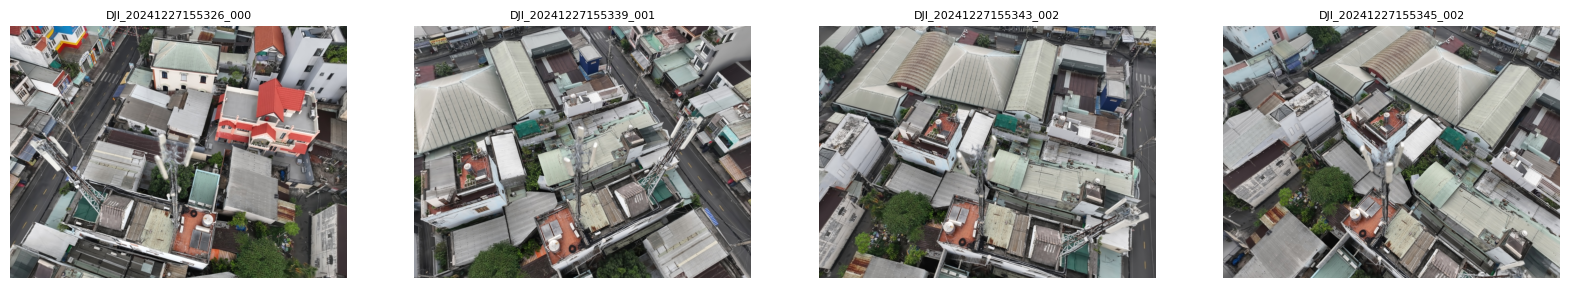

50 ảnh trong /kaggle/working/output/hcm0031/test_renders


In [34]:
import matplotlib.pyplot as plt
from PIL import Image
import os
d = f"{MODEL}/test_renders"
fs = sorted(os.listdir(d))[:4]
plt.figure(figsize=(20, 5))
for i, f in enumerate(fs):
    plt.subplot(1, 4, i + 1)
    plt.imshow(Image.open(os.path.join(d, f)))
    plt.axis("off"); plt.title(f[:22], fontsize=8)
plt.show()
print(len(os.listdir(d)), "ảnh trong", d)

## 7. (Tuỳ chọn) Chạy TẤT CẢ scene — có status.json để resume

Đổi `RUN_ALL = True`. Tiến độ ghi vào `/kaggle/working/output/status.json`
sau mỗi bước; chạy lại cell là tiếp tục đúng chỗ, scene xong rồi tự skip.

In [ ]:
RUN_ALL = True   # <-- True để chạy hết mọi scene trong DATA_ROOT
if RUN_ALL:
    !python {PIPE}/run_all_kaggle.py --data {DATA_ROOT} --pipe {PIPE} \
        --out /kaggle/working/output --iters {ITERS} --eval

Tổng 5 scene | đã xong 0: []

===== HCM0181 =====
>> python /kaggle/working/pipeline/prepare_scene.py --scene /kaggle/input/datasets/huphcphmquang/viettel-ai-2026/phase1/public_set/HCM0181 --out /kaggle/working/scenes/HCM0181
[camera] id=1 SIMPLE_RADIAL k=0.00900 -> PINHOLE (926.44, 926.44, 660.0, 494.5)  (sẽ undistort ảnh)
[images.bin] 371 entry -> giữ 240 (khớp 240 file train)
[undistort] 50/240
[undistort] 100/240
[undistort] 150/240
[undistort] 200/240
[undistort] xong 240 ảnh (k=0.00900)
[prepare] OK -> /kaggle/working/scenes/HCM0181/train
>> cd /kaggle/working/gaussian-splatting && python train.py -s /kaggle/working/scenes/HCM0181/train -m /kaggle/working/output/HCM0181 --iterations 7000 --save_iterations 7000 --test_iterations 7000 -r 1
Optimizing /kaggle/working/output/HCM0181
Output folder: /kaggle/working/output/HCM0181 [08/07 03:32:14]
Reading camera 240/240 [08/07 03:32:15]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [08/07 03:32:15]


In [ ]:
import os, json, csv

DATA = DATA_ROOT                      # từ cell config (public_set)
OUT  = "/kaggle/working/output"

# ---- 1. status.json: scene nào xong, scene nào dở/lỗi ----
st = json.load(open(f"{OUT}/status.json")) if os.path.exists(f"{OUT}/status.json") else {}
scenes = sorted(d for d in os.listdir(DATA) if os.path.isdir(f"{DATA}/{d}"))
print(f"{'scene':12} {'prepare':8} {'train':6} {'render':7} {'ảnh':>9} {'phút':>6}  ghi chú")
print("-" * 70)
for s in scenes:
    v = st.get(s, {})
    # đếm ảnh render vs số pose trong CSV
    rdir = f"{OUT}/{s}/test_renders"
    n_render = len(os.listdir(rdir)) if os.path.isdir(rdir) else 0
    with open(f"{DATA}/{s}/test/test_poses.csv") as f:
        n_pose = sum(1 for _ in csv.DictReader(f))
    mins = round(v.get("sec", 0) / 60) if v.get("sec") else ""
    note = v.get("error", "")[:30] if v.get("error") else ("OK" if n_render == n_pose else f"THIẾU {n_pose-n_render} ảnh!")
    print(f"{s:12} {v.get('prepare','-'):8} {v.get('train','-'):6} {v.get('render','-'):7} "
          f"{n_render:>4}/{n_pose:<4} {mins:>6}  {note}")

# ---- 2. PSNR các scene đã render (public có GT) ----
print("\n--- PSNR ---")
for s in scenes:
    rdir, gt = f"{OUT}/{s}/test_renders", f"{DATA}/{s}/test/images"
    if os.path.isdir(rdir) and os.listdir(rdir) and os.path.isdir(gt):
        print(f"[{s}]", end=" ")
        !python {PIPE}/eval_metrics.py --renders {rdir} --gt {gt}

# ---- 3. Dung lượng /kaggle/working (giới hạn ~20GB) ----
print("\n--- Disk ---")
!du -sh /kaggle/working/output /kaggle/working/scenes 2>/dev/null
!df -h /kaggle/working | tail -1

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

done = [s for s in sorted(os.listdir(OUT))
        if os.path.isdir(f"{OUT}/{s}/test_renders") and os.listdir(f"{OUT}/{s}/test_renders")]
plt.figure(figsize=(18, 4.5 * len(done)))
for r, s in enumerate(done):
    d = f"{OUT}/{s}/test_renders"
    fs = sorted(os.listdir(d))
    for c, f in enumerate([fs[0], fs[len(fs)//2], fs[-1]]):   # đầu / giữa / cuối
        plt.subplot(len(done), 3, r*3 + c + 1)
        plt.imshow(Image.open(os.path.join(d, f)))
        plt.axis("off"); plt.title(f"{s} | {f[:20]}", fontsize=8)
plt.tight_layout(); plt.show()

## 8. Đóng gói ảnh render + in trạng thái

In [ ]:
import shutil, os
OUT, SUB = "/kaggle/working/output", "/kaggle/working/submission"
os.makedirs(SUB, exist_ok=True)
for scene in sorted(os.listdir(OUT)):
    if not os.path.isdir(f"{DATA_ROOT}/{scene}"):
        continue   # chỉ đóng gói scene thuộc DATA_ROOT hiện tại
    r = f"{OUT}/{scene}/test_renders"
    if os.path.isdir(r):
        shutil.copytree(r, f"{SUB}/{scene}", dirs_exist_ok=True)
        print(scene, "->", len(os.listdir(r)), "ảnh")
shutil.make_archive("/kaggle/working/submission", "zip", SUB)
print("submission.zip:", round(os.path.getsize("/kaggle/working/submission.zip")/1e6, 1), "MB")
st = f"{OUT}/status.json"
if os.path.exists(st):
    print(open(st).read())